# Micro-ring resonator

Micro-ring resonator on silicon-on-insulator (SOI) 

## Parameters

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import luminescent as lm

# simulation folder
path = os.path.join('runs', 'ring')

# length units are arbitrary so long as they are consistent, in this case [um]. everything gets normalized around origin wavelength and period at backend.
wavelength = 1.55  # characteristic wavelength [um]
bandwidth = 0.1  # wavelength bandwidth [um]
wavelengths = np.linspace(wavelength - bandwidth / 2, wavelength + bandwidth / 2, 401)

# vertical midplane symmetry as PMC boundary on z-
boundaries = ['PML', ('PEC', 'PML'), ('PMC', 'PML')]  # z midplane PMC symmetry

# horizontal dims
r = 3.1  # radius of ring
w_wg = 0.4  # width of waveguide
gap = 0.1  # gap between waveguide and ring

source_offset = 2
xmargin = 1.5 
ymargin = lateral_port_margin = 1 

# vertical dims
h_wg = 0.18  # height of waveguide

zmargin = height_port_margin = 1 
zmin = 0
zmax = h_wg / 2 + zmargin

# simulation parameters
nres = 6  # number of grid points per wavelength in material (not vacuum)
stop_decay = 0.003
relative_courant = 0.95  # Courant factor for time step size, relative to max allowed by grid
subpixel_smoothing = 1
PML_decay = [.001,.1,.1]
tmax = 1000  # max time [periods]

frame_every = 10  # save and plot field every _ periods, involves slow disk write
views = [lm.View("Hz", x=0, z=0)]

# materials
material_core = 'Si'
material_clad = 'SiO2'
background = material_clad
materials = {
    'Si': lm.Material(3.5),
    'SiO2': lm.Material(1.5),
}

# layer stack
WG = (1, 0)  # waveguide layer
BBOX = (10, 0)  # bounding box layer
layer_stack = LayerStack(
    layers={
        'core': LayerLevel(
            layer=LogicalLayer(layer=WG),
            thickness=h_wg / 2,
            zmin=0.0,
            material=material_core,
            mesh_order=1,
        )    })

## Geometry

2 symmetries:
- mid waveguide height z PMC boundary
- ring section y PEC boundary (implies fictious mirror source at port o2 on other side of ring. original S21 turns into S11 in our mirror setup assuming no back coupling)

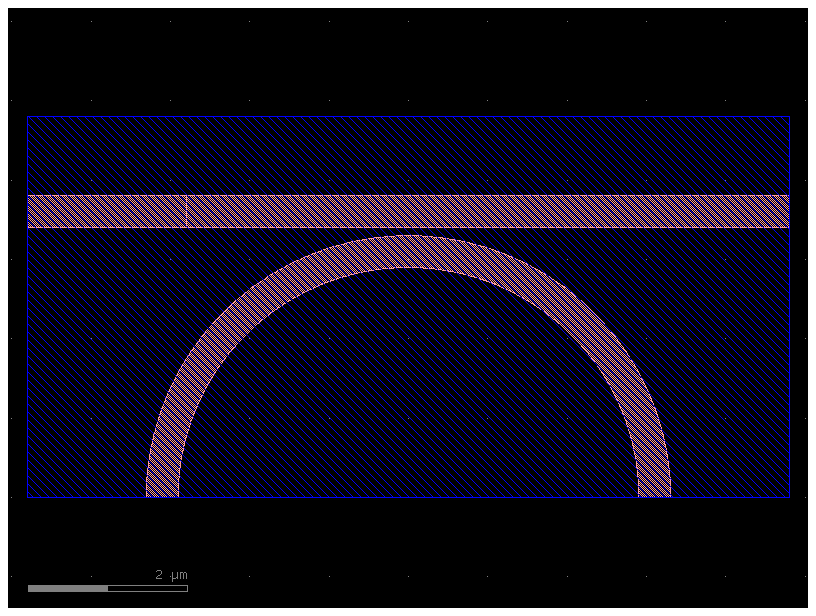

In [7]:
# make component in gdsfactory. alternatively, you can import .gds layout into gdsfactory or .stl bodies directly into ours
c = gf.Component()

b = c << gf.components.bend_circular180(radius=r, width=w_wg, layer=WG, allow_min_radius_violation=True)
b.rotate(90)
b.movex(r)

l = 2 * r + 2 * xmargin + w_wg
s = c << gf.components.straight(length=l - source_offset, width=w_wg)
s.move((-l / 2 + source_offset, w_wg + gap + r))

s1 = c << gf.components.straight(length=source_offset, width=w_wg)
s1.connect('o2', s.ports['o1'])

c.add_port('o1', port=s.ports['o1'])
c.add_port('o3', port=s.ports['o2'])
c << gf.components.bbox(component=c, layer=BBOX, top=ymargin)
c.plot()


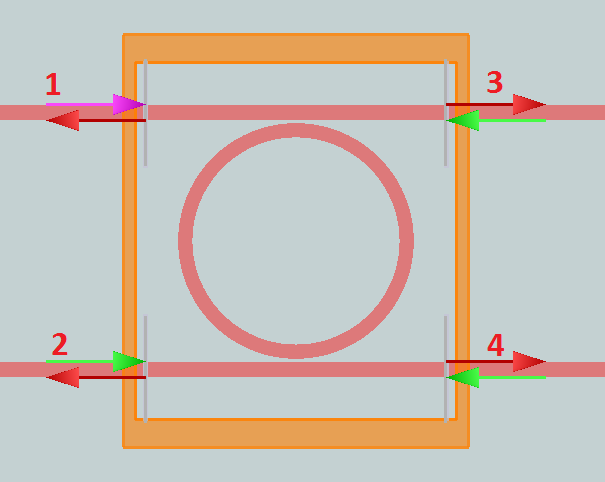

## Setup

origin: [-2.8000000000000003, 3.6, 0.0], frame: [[-1.2246467991473532e-16, -1.0, 0], [0, 0, 1], [-1.0, 1.2246467991473532e-16, 0]], start: [-1.2, 0], stop: [1.2, 1.09],
polyeps: [(<POLYGON ((-0.2 1.184e-5, -0.2 0.09, -0.2 0.09, 0.2 0.09, 0.2 0.09, 0.2 0, -...>, 12.25, 'core'), (<POLYGON ((-0.2 0.09, 0.2 0.09, 0.2 2.25e-9, -0.2 0, -0.2 0.09))>, 12.25, 'core'), (<POLYGON ((1.2 0, 1.2 1.09, -1.2 1.09, -1.2 0, 1.2 0))>, 2.25, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 0A00


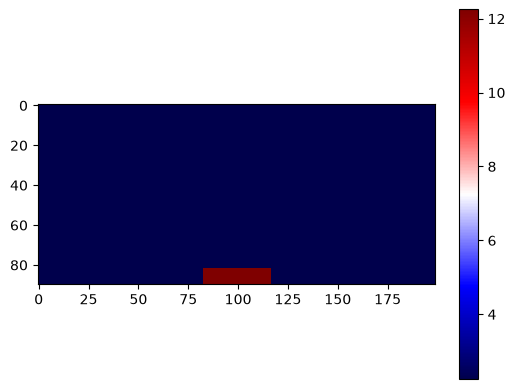

wg_mode/1.55 mode 0 (neff=2.191+0.000j)
saving mode to /home/weihu/moon/luminescent/runs/ring/modes/wg_mode/1.55/0.npz
using simulation folder /home/weihu/moon/luminescent/runs/ring


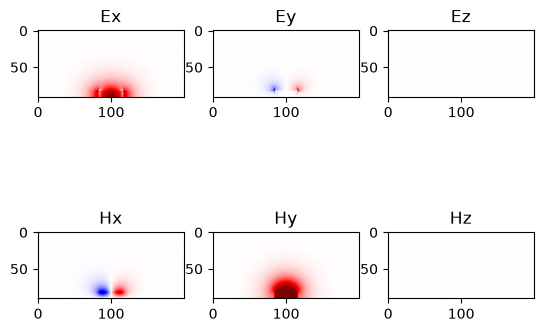

In [ ]:
bbox = c.bbox_np().tolist()
bbox[0].append(zmin)
bbox[1].append(zmax)

# source and modes setup
w_port = w_wg + 2 * lateral_port_margin
h_port = h_wg + 2 * height_port_margin

sensors = [
    lm.Sensor(name='wg_mode', mode_solver_wavelengths=[wavelength], start=[-w_port / 2, zmin], stop=[w_port / 2, zmax], boundaries=['PML', ['PMC', 'PML']], nmodes=1, modes='auto'),  # local xy frame
    lm.Sensor(name='wg_signal', points=[[0,0]], time_response=True),
]

origin, frame = lm.from_gf_port(c, 'o1', source_offset)
sources = [lm.Source('o1', origin, frame, sensor='wg_mode', wavelength=wavelength, bandwidth=wavelength / 5)]

t0=100
monitors = [
    lm.Monitor('o1_mode', *lm.from_gf_port(c, 'o1'), sensor='wg_mode'),
    lm.Monitor('o3_mode', *lm.from_gf_port(c, 'o3'), sensor='wg_mode', mirrored=True),
    lm.Monitor('o1_signal', *lm.from_gf_port(c, 'o1'), sensor='wg_signal', t0=t0)
]

lm.mesh(path, c, layer_stack, materials, zmin, zmax)
lm.setup(
    path=path,
    wavelength=wavelength,
    wavelengths=wavelengths,
    materials=materials,
    background=background,
    boundaries=boundaries,
    bbox=bbox,
    # 
    sensors=sensors,
    sources=sources,
    monitors=monitors,
    # 
    nres=nres,
    relative_courant=relative_courant,
    dtype='f16',
    subpixel_smoothing=subpixel_smoothing,
    tmax=tmax,
    PML_decay=PML_decay,
    # 
    views=views,
    frame_every=frame_every,
    stop_decay=stop_decay,
)


## Solve

In [ ]:
lm.solve(path)

## Movie

Video generated successfully at /home/weihu/moon/luminescent/runs/ring/simulation.gif!


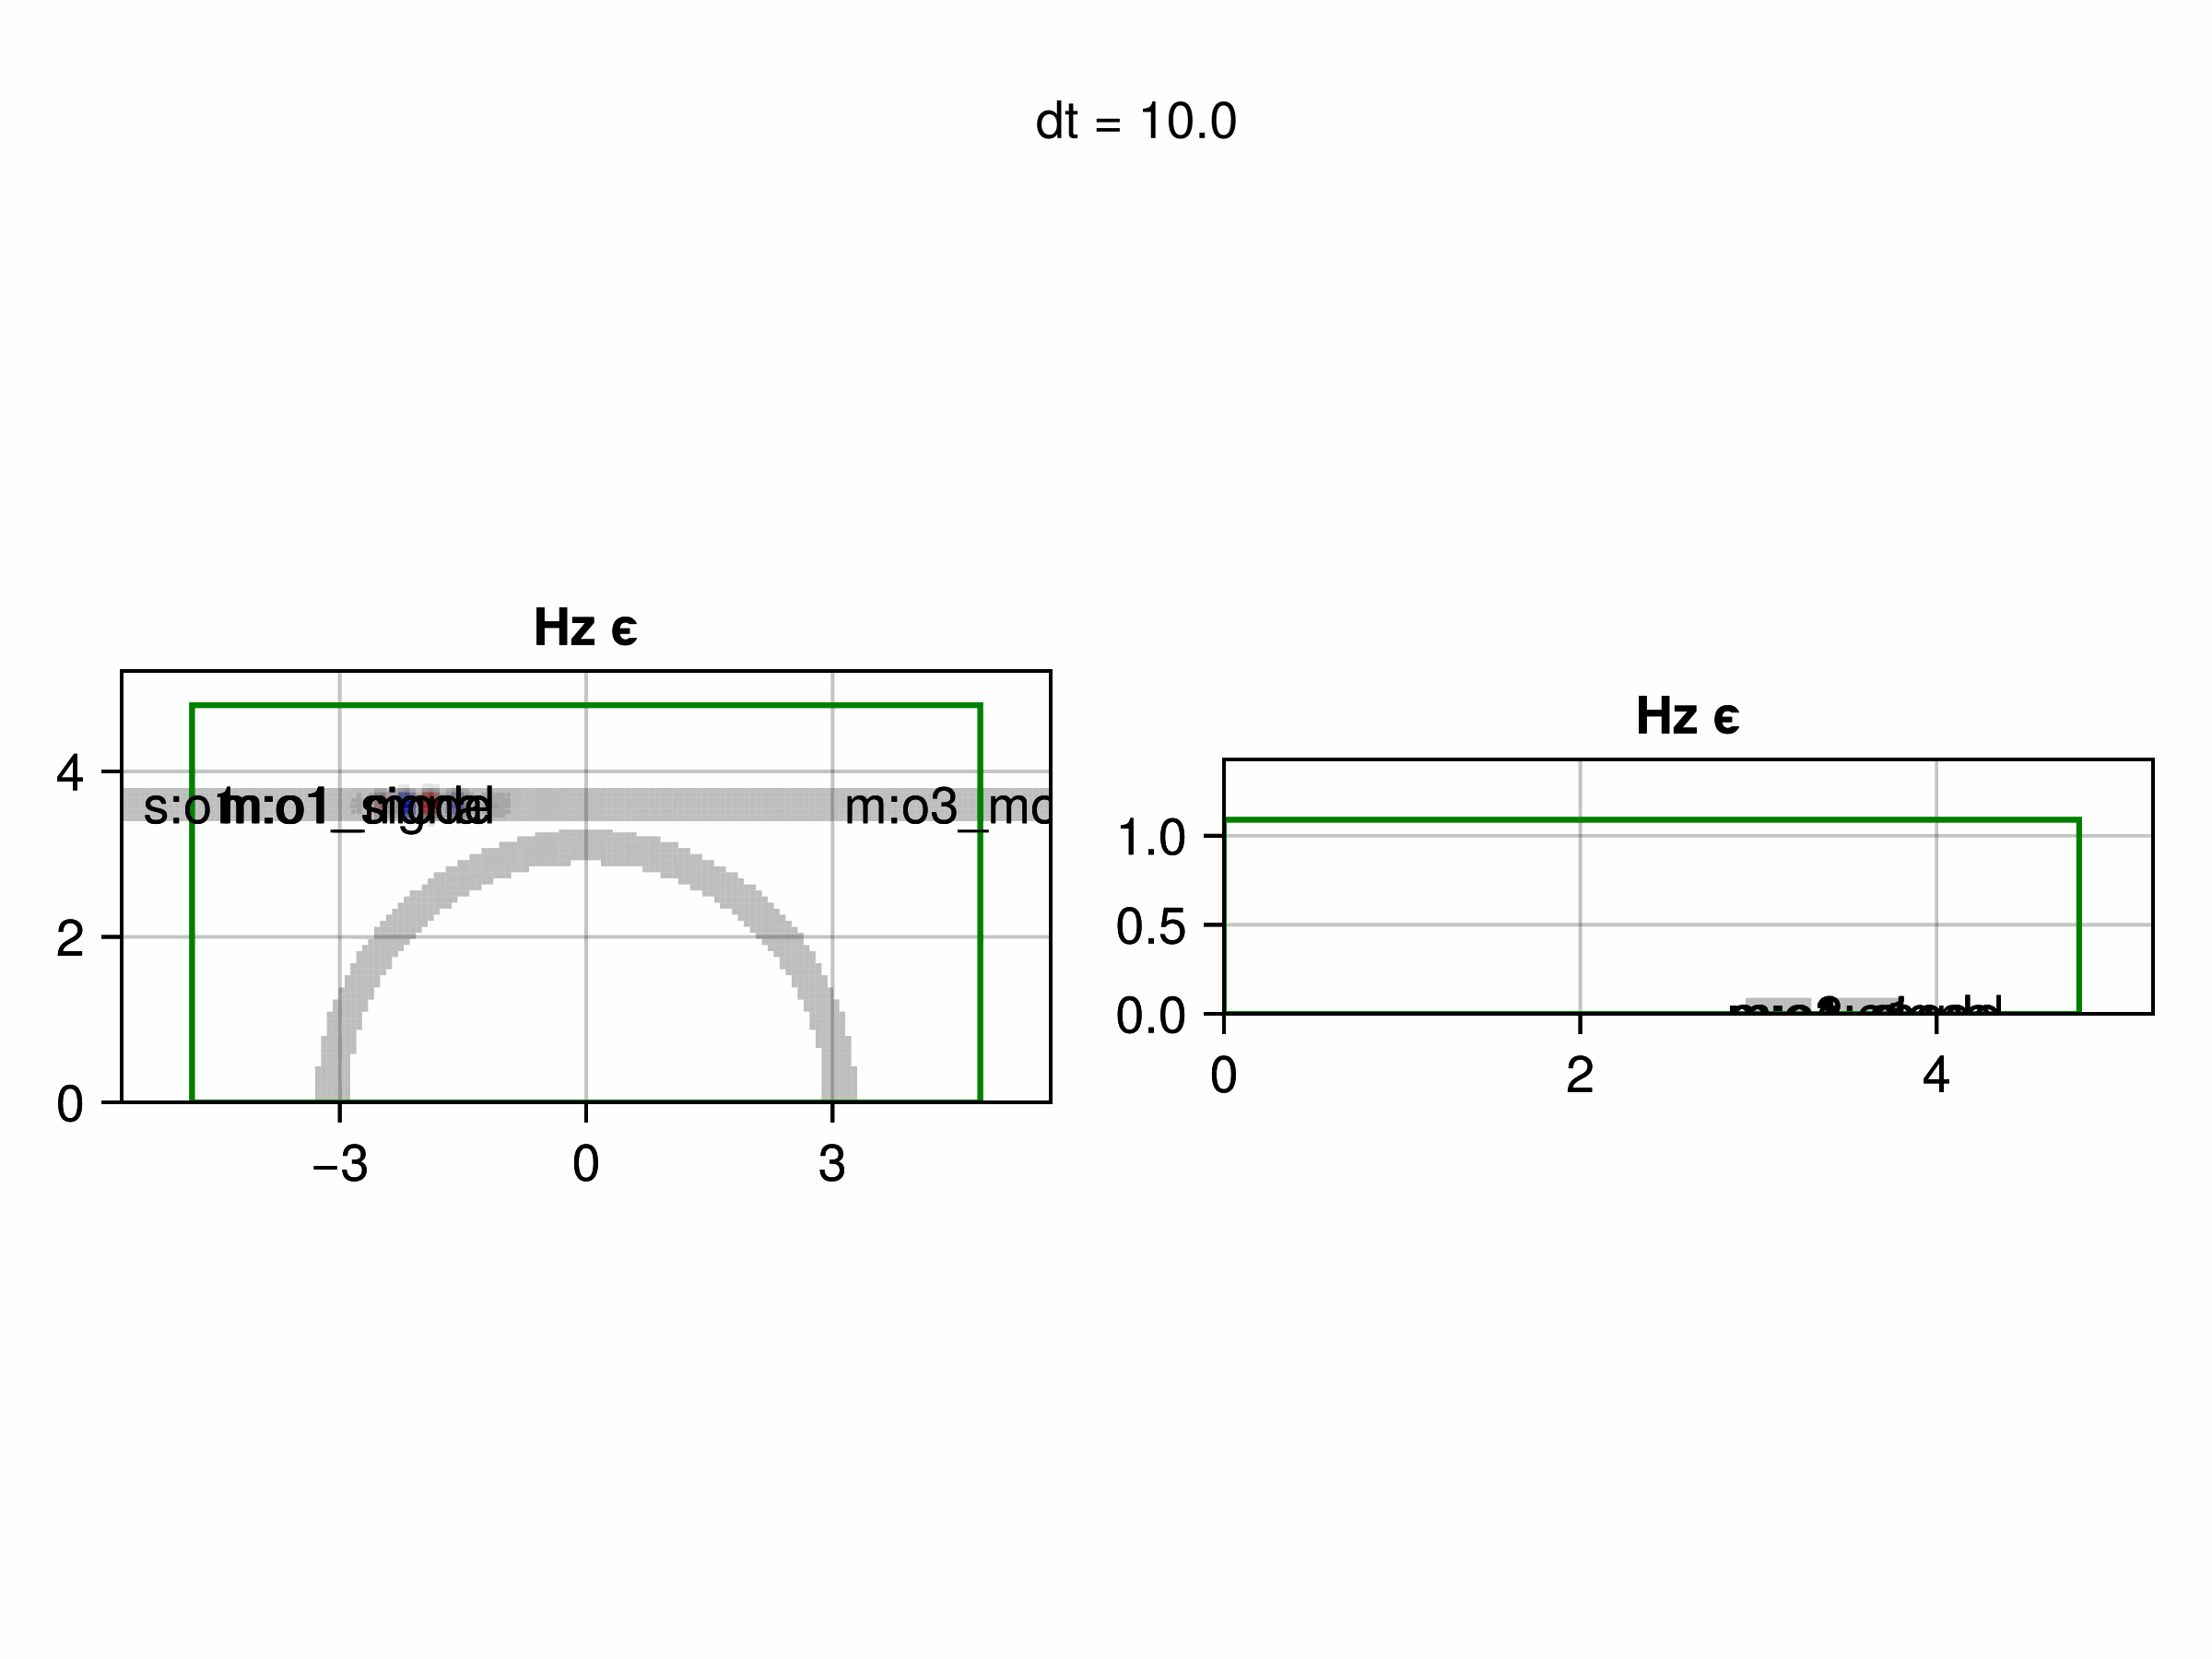

In [11]:
lm.movie(path)

## Results


### S parameters

loading solution from /home/weihu/moon/luminescent/runs/ring
may take a minute if simulation folder is remotely mounted


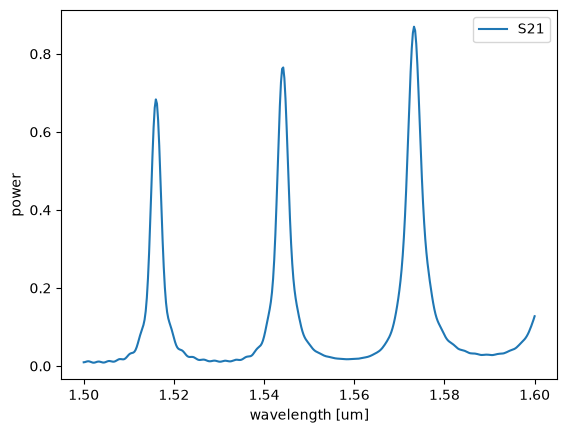

In [17]:
sol = lm.load(path)

S21 = sol['o1_mode']['modes']['+'] / sol['o1_mode']['modes']['-'] # drop port power
S31 = sol['o3_mode']['modes']['+'] / sol['o1_mode']['modes']['-'] # through port power

plt.plot(wavelengths, np.abs(S21)**2, label="S21")
# plt.plot(wavelengths, S31, label="S31")

plt.xlabel("wavelength [um]")
plt.ylabel("power")
plt.legend()
plt.show()

### Resonances

In [13]:
from scipy.signal import find_peaks

dw=bandwidth/len(wavelengths)
I, props = find_peaks(S21, height=0.4, distance=.01//dw)

peaks = wavelengths[I]
print(f'Peaks: {"nm ".join([ f"{1000*x:.2f}" for x in peaks])}')

Peaks: 1517.00


/home/weihu/.local/lib/python3.14/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


### FSR

In [14]:
FSR = np.mean(np.diff(peaks))
print(f'FSR: {1000*FSR:.2f}nm')

FSR: nannm


/home/weihu/.local/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/weihu/.local/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Q factor (FWHM method)

In [15]:
i=len(I)//2
mid = I[i]
half =props['peak_heights'][i]/2        # use S21[mid]-3 if S21 is in dB

l = mid
while S21[l] > half: l -= 1
wl_lo = wavelengths[l]

r = mid
while S21[r] > half: r += 1
wl_hi = wavelengths[r]

FWHM = wl_hi - wl_lo
wl=wavelengths[mid]
Q=wl/FWHM
print(f'FWHM: {1000*FWHM:.2f}nm\nQ factor (FWHM method): {Q:.0f}')

FWHM: 3.25nm
Q factor (FWHM method): 467


# Early stopping (advanced)

Can still get FSR and Q factor by stopping early. Saves time because high Q cavity takes long time to decay completely. Instead simulate for only long enough for resonances to settle into decay trend. Here, can set `energy_decay_threshold=.1` 

Stopping early in time domain convolves sinc blur in frequency domain. Can still extract resonances and FSR from blurred spectrum, but Q factor must be computed from time domain decay signal.

## Q factor (time domain decay method)

/tmp/ipykernel_26003/1901965254.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


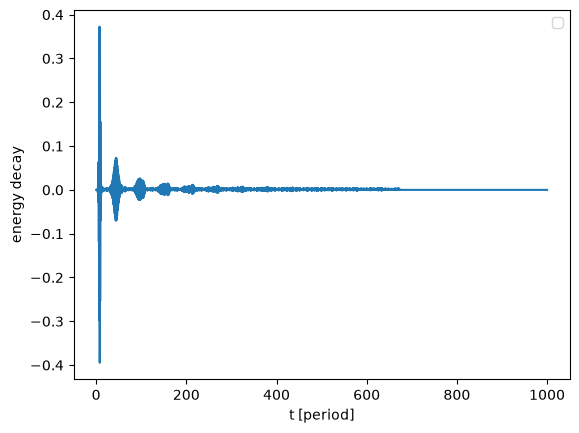

In [ ]:
t=sol['t']
y = sol['o1_signal']['signals']['Ex'][0,:]

plt.plot(t, y)
plt.xlabel("t [period]")
plt.ylabel("o2 Ex (monitor frame of reference)")
plt.legend()
plt.show()

In [ ]:
# exercise to reader: use harmonic inversion tool eg harminv to extract Q factor

fmin=1.5/1.55
fmax=1.6/1.55
dt=t[1]-t[0]

# np.savetxt("in.txt", y)
# os.system(f"harminv -t {dt} {fmin}-{fmax} < in.txt > out.txt")
# print(f'Q factor (time decay method): {Q:.0f}')

0